<a href="https://colab.research.google.com/github/guilhermegoldmam/UENFMESTRADO/blob/main/CLIMA_URBANO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install cdsapi
%pip install netcdf4

import cdsapi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.1 MB/s eta 0:00:00


In [ ]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "2m_temperature"
    ],
    "year": ["2025"],
    "month": ["01"],
    "day": ["15"],
    "time": ["15:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [90, -180, -90, 180]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='6fff0335-1b30-4f92-9857-684fb8d68829', verify=False)
client.retrieve(dataset, request).download()


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-06-30 17:21:14,494 INFO Request 

2588f65b46aa55c16c1ab8e8ee9a72f.nc:   0%|          | 0.00/3.43M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


'2588f65b46aa55c16c1ab8e8ee9a72f.nc'

In [ ]:
# Colab only
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import xarray as xr
import pandas as pd


In [ ]:
ds = xr.open_dataset('2588f65b46aa55c16c1ab8e8ee9a72f.nc',engine='h5netcdf')

df_converted = ds.to_dataframe()

print('Dataset converted to DataFrame and saved to output_data_irradiance.csv')

Dataset converted to DataFrame and saved to output_data_irradiance.csv


In [ ]:
import cdsapi

dataset = "derived-drought-historical-monthly"
request = {
    "variable": ["standardised_precipitation_index"],
    "accumulation_period": ["1"],
    "version": "1_0",
    "product_type": ["reanalysis"],
    "dataset_type": "consolidated_dataset",
    "year": ["2015"],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "area": [-13, -53, -26, -38]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='6fff0335-1b30-4f92-9857-684fb8d68829', verify=False)
client.retrieve(dataset, request).download()

ModuleNotFoundError: No module named 'cdsapi'

In [ ]:
import os

print(os.listdir())

['.config', '2588f65b46aa55c16c1ab8e8ee9a72f.nc', '6fcfbdc3e8fd07d0e4042bb10d9e4a54.zip', 'drive', 'era5_data', 'sample_data']


In [ ]:
import xarray as xr

ds = xr.open_dataset("2588f65b46aa55c16c1ab8e8ee9a72f.nc")
print(ds)

<xarray.Dataset> Size: 8MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2025-01-15T15:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 4MB ...
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-30T17:21 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
import xarray as xr

ds = xr.open_dataset("2588f65b46aa55c16c1ab8e8ee9a72f.nc")

print(ds)

<xarray.Dataset> Size: 8MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2025-01-15T15:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 4MB ...
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-30T17:21 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
print(dataset)

derived-drought-historical-monthly


In [ ]:
print(request)

{'variable': ['standardised_precipitation_index'], 'accumulation_period': ['1'], 'version': '1_0', 'product_type': ['reanalysis'], 'dataset_type': 'consolidated_dataset', 'year': ['2015'], 'month': ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12'], 'area': [-13, -53, -26, -38]}


In [ ]:
import os

for arquivo in os.listdir():
    print(arquivo)

.config
2588f65b46aa55c16c1ab8e8ee9a72f.nc
6fcfbdc3e8fd07d0e4042bb10d9e4a54.zip
drive
era5_data
sample_data


In [ ]:
import zipfile

with zipfile.ZipFile("6fcfbdc3e8fd07d0e4042bb10d9e4a54.zip", "r") as zip_ref:
    zip_ref.extractall("spi")

In [ ]:
import os

os.listdir("spi")

['SPI1_gamma_global_era5_moda_ref1991to2020_201506.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201502.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201508.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201510.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201507.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201512.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201503.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201505.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201501.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201504.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201511.area-subset.-13.-38.-26.-53.nc',
 'SPI1_gamma_global_era5_moda_ref1991to2020_201509.area-subset.-13.-38.-26.-

In [ ]:
import xarray as xr

ds = xr.open_dataset(
    "spi/SPI1_gamma_global_era5_moda_ref1991to2020_201501.area-subset.-13.-38.-26.-53.nc"
)

print(ds)

<xarray.Dataset> Size: 27kB
Dimensions:  (time: 1, lat: 53, lon: 61)
Coordinates:
  * time     (time) datetime64[ns] 8B 2015-01-01T06:00:00
  * lat      (lat) float64 424B -13.0 -13.25 -13.5 -13.75 ... -25.5 -25.75 -26.0
  * lon      (lon) float64 488B -53.0 -52.75 -52.5 -52.25 ... -38.5 -38.25 -38.0
Data variables:
    SPI1     (time, lat, lon) float64 26kB ...
Attributes: (12/19)
    title:                   SPI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 28/10/2024 22:25:59 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    ref_publication:         Keune, J., Di Giuseppe, F., Barnard, C., Damasio...
    cds_data_catalogue_url:  https://cds.climate.copernicus.eu/datasets/

In [ ]:
import zipfile
import os

# Certifica-se de que o diretório 'spi' existe
if not os.path.exists("spi"):
    os.makedirs("spi")

# Re-extrair o arquivo zip para a pasta 'spi' para garantir que os dados estejam disponíveis.
# O nome do arquivo zip é '6fcfbdc3e8fd07d0e4042bb10d9e4a54.zip' conforme o histórico.
with zipfile.ZipFile("6fcfbdc3e8fd07d0e4042bb10d9e4a54.zip", "r") as zip_ref:
    zip_ref.extractall("spi")

print("Arquivo zip re-extraído para a pasta 'spi'.")

FileNotFoundError: [Errno 2] No such file or directory: '6fcfbdc3e8fd07d0e4042bb10d9e4a54.zip'

In [ ]:
import xarray as xr

# Ensure the SPI-1 data for January 2015 is loaded.
ds = xr.open_dataset(
    "spi/SPI1_gamma_global_era5_moda_ref1991to2020_201501.area-subset.-13.-38.-26.-53.nc"
)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/spi/SPI1_gamma_global_era5_moda_ref1991to2020_201501.area-subset.-13.-38.-26.-53.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
print(ds.data_vars)

Data variables:
    SPI1     (time, lat, lon) float64 26kB ...


In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 64.0 MB/s eta 0:00:00


NameError: name 'ds' is not defined

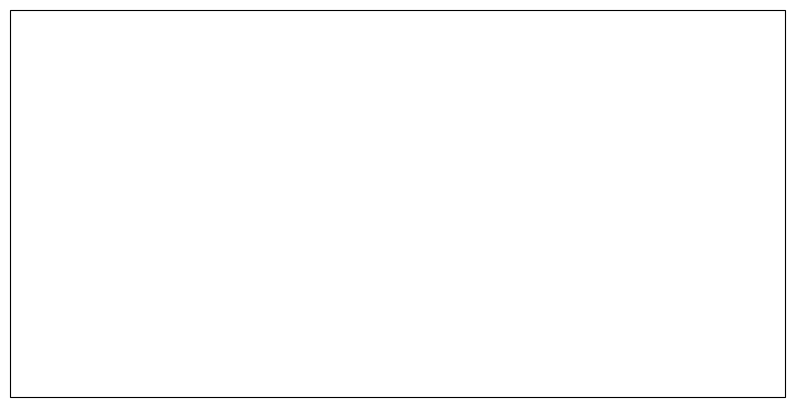

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# The dataset 'ds' is assumed to be loaded from a previous cell (HTvR7he1zvgT)

# Criar figura
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plotar o SPI
ds["SPI1"].isel(time=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu",
    cbar_kwargs={"label": "SPI-1"}
)

# Adicionar elementos do mapa
ax.coastlines(resolution="10m")
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, edgecolor="black")
ax.add_feature(cfeature.OCEAN)

# Grade
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.title("SPI-1 - Janeiro de 2015") # Revert to a general title
plt.show()

In [ ]:
!pip install cdsapi

In [ ]:
import cdsapi

dataset = "sis-agrometeorological-indicators"
request = {
    "variable": "solar_radiation_flux",
    "year": ["2015"],
    "month": ["01"],
    "day": ["22"],
    "version": "2_0",
    "area": [-1.75, -49.2, -2.25, -48.7]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='6fff0335-1b30-4f92-9857-684fb8d68829', verify=False)
client.retrieve(dataset, request).download()



/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-07-01 14:33:47,873 INFO [2026-06

279e018ff96a38cd40ecbc3e7cf4fc9b.zip:   0%|          | 0.00/25.3k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


'279e018ff96a38cd40ecbc3e7cf4fc9b.zip'

In [ ]:
import zipfile

with zipfile.ZipFile("279e018ff96a38cd40ecbc3e7cf4fc9b.zip", "r") as zip_ref:
    zip_ref.extractall("radiacao")

In [ ]:
import os

os.listdir("radiacao")

['Solar-Radiation-Flux_C3S-glob-agric_AgERA5_20150122_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc']

In [ ]:
import xarray as xr

ds = xr.open_dataset("Solar-Radiation-Flux_C3S-glob-agric_AgERA5_20150122_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc")

print(ds)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/Solar-Radiation-Flux_C3S-glob-agric_AgERA5_20150122_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import os

print(os.listdir())
print("-------------------")
print(os.listdir("radiacao"))

['.config', 'radiacao', 'spi', 'drive', '279e018ff96a38cd40ecbc3e7cf4fc9b.zip', 'sample_data']
-------------------
['Solar-Radiation-Flux_C3S-glob-agric_AgERA5_20150122_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc']


In [ ]:
import xarray as xr

ds = xr.open_dataset(
    "radiacao/Solar-Radiation-Flux_C3S-glob-agric_AgERA5_20150122_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc"
)

print(ds)

<xarray.Dataset> Size: 196B
Dimensions:               (time: 1, lat: 5, lon: 5)
Coordinates:
  * time                  (time) datetime64[ns] 8B 2015-01-22
  * lat                   (lat) float64 40B -1.8 -1.9 -2.0 -2.1 -2.2
  * lon                   (lon) float64 40B -49.1 -49.0 -48.9 -48.8 -48.7
Data variables:
    Solar_Radiation_Flux  (time, lat, lon) float32 100B ...
    crs                   (time) int64 8B ...
Attributes:
    Conventions:  CF-1.7
    title:        AgERA5 daily weather variables derived from the ECMWF ERA5 ...
    institution:  Wageningen Environmental Research
    history:      Generated by `pragera5 run_daily_processing 2015-01-22` ver...
    references:   https://doi.org/10.24381/cds.6c68c9bb
    source:       ECWMF ERA5 reanalysis, https://doi.org/10.24381/cds.143582cf


In [ ]:
print(ds["Solar_Radiation_Flux"])

<xarray.DataArray 'Solar_Radiation_Flux' (time: 1, lat: 5, lon: 5)> Size: 100B
[25 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2015-01-22
  * lat      (lat) float64 40B -1.8 -1.9 -2.0 -2.1 -2.2
  * lon      (lon) float64 40B -49.1 -49.0 -48.9 -48.8 -48.7
Attributes:
    units:                 J m-2 d-1
    grid_mapping:          crs
    long_name:             Surface solar radiation downwards (00-00LT)
    temporal_aggregation:  Sum 00-00LT


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


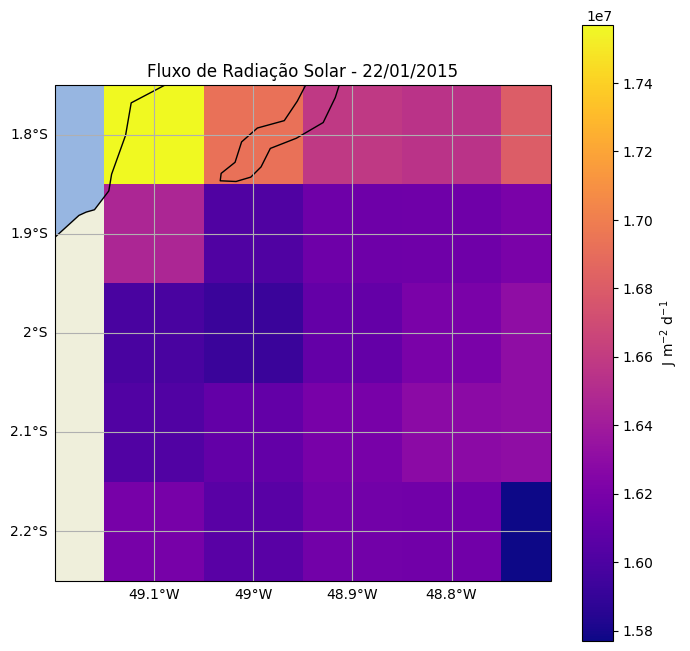

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plotar o fluxo de radiação
ds["Solar_Radiation_Flux"].isel(time=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="plasma",
    cbar_kwargs={"label": "J m$^{-2}$ d$^{-1}$"}
)

# Elementos do mapa
ax.coastlines(resolution="10m")
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)

# Limites da área
ax.set_extent([-49.2, -48.7, -2.25, -1.75], crs=ccrs.PlateCarree())

# Grade
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.title("Fluxo de Radiação Solar - 22/01/2015")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.9 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


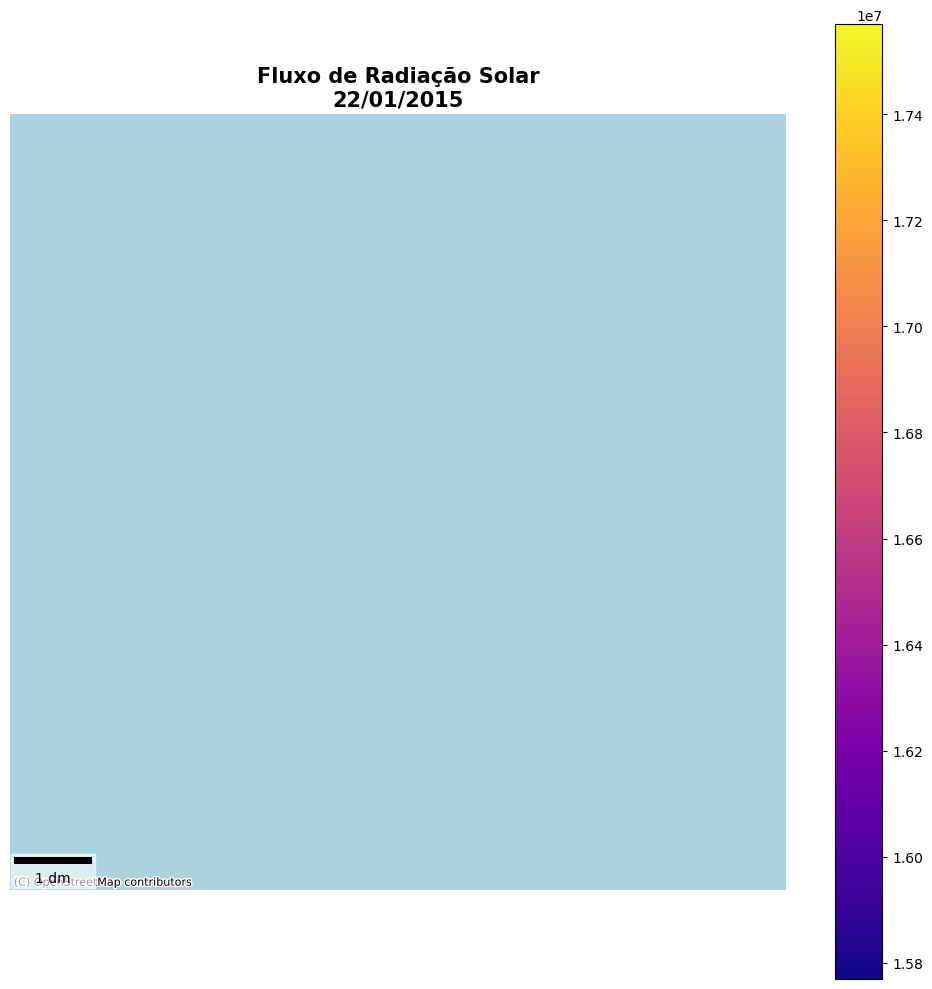

In [ ]:
# Instale as bibliotecas (caso necessário)
!pip install contextily geopandas matplotlib shapely matplotlib-scalebar rioxarray

import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# ===========================
# ABRIR O ARQUIVO
# ===========================

ds = xr.open_dataset(
    "radiacao/Solar-Radiation-Flux_C3S-glob-agric_AgERA5_20150122_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc"
)

# Seleciona a variável
rad = ds["Solar_Radiation_Flux"].isel(time=0)

# Converte para DataFrame
df = rad.to_dataframe().reset_index()

# Cria GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# Converte para Web Mercator
gdf = gdf.to_crs(epsg=3857)

# ===========================
# MAPA
# ===========================

fig, ax = plt.subplots(figsize=(10,10))

# Fundo OpenStreetMap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=11
)

# Plot dos dados
gdf.plot(
    ax=ax,
    column="Solar_Radiation_Flux",
    cmap="plasma",
    legend=True,
    markersize=220,
    alpha=0.9
)

# Barra de escala
scalebar = ScaleBar(
    1,
    units="m",
    location="lower left",
    box_alpha=0.6
)

ax.add_artist(scalebar)

# Remove eixos
ax.set_axis_off()

plt.title(
    "Fluxo de Radiação Solar\n22/01/2015",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "Fluxo_Radiacao_Igarape_Miri.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(rad.values)

[[17569490. 16928040. 16583898. 16547904. 16805540.]
 [16463214. 16009558. 16142548. 16150891. 16202874.]
 [15985268. 15921224. 16104569. 16201214. 16307915.]
 [16018237. 16095253. 16193705. 16285693. 16309651.]
 [16184881. 16054673. 16165082. 16157824. 15769723.]]


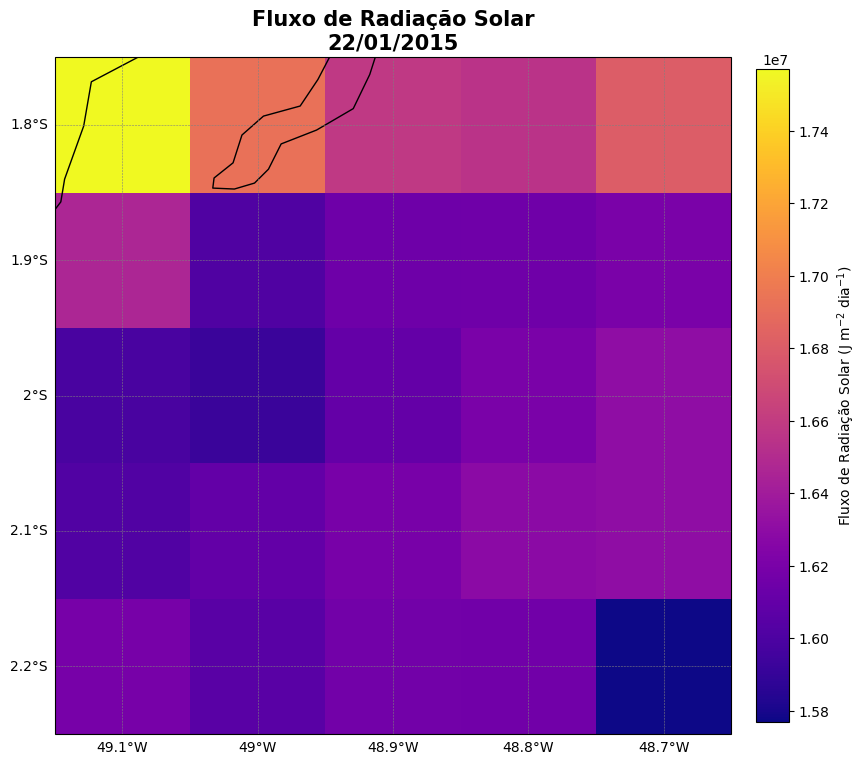

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(9,9))
ax = plt.axes(projection=ccrs.PlateCarree())

# Dados
lon = ds.lon.values
lat = ds.lat.values
rad = ds["Solar_Radiation_Flux"].isel(time=0).values

# Raster
pcm = ax.pcolormesh(
    lon,
    lat,
    rad,
    cmap="plasma",
    shading="nearest",
    transform=ccrs.PlateCarree()
)

# Elementos do mapa
ax.coastlines("10m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5")
ax.add_feature(cfeature.OCEAN, facecolor="#bcdff5")

# Grade
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    linestyle="--",
    color="gray"
)

gl.top_labels = False
gl.right_labels = False

# Barra de cores
cbar = plt.colorbar(
    pcm,
    ax=ax,
    shrink=0.75,
    pad=0.03
)

cbar.set_label("Fluxo de Radiação Solar (J m$^{-2}$ dia$^{-1}$)")

plt.title(
    "Fluxo de Radiação Solar\n22/01/2015",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


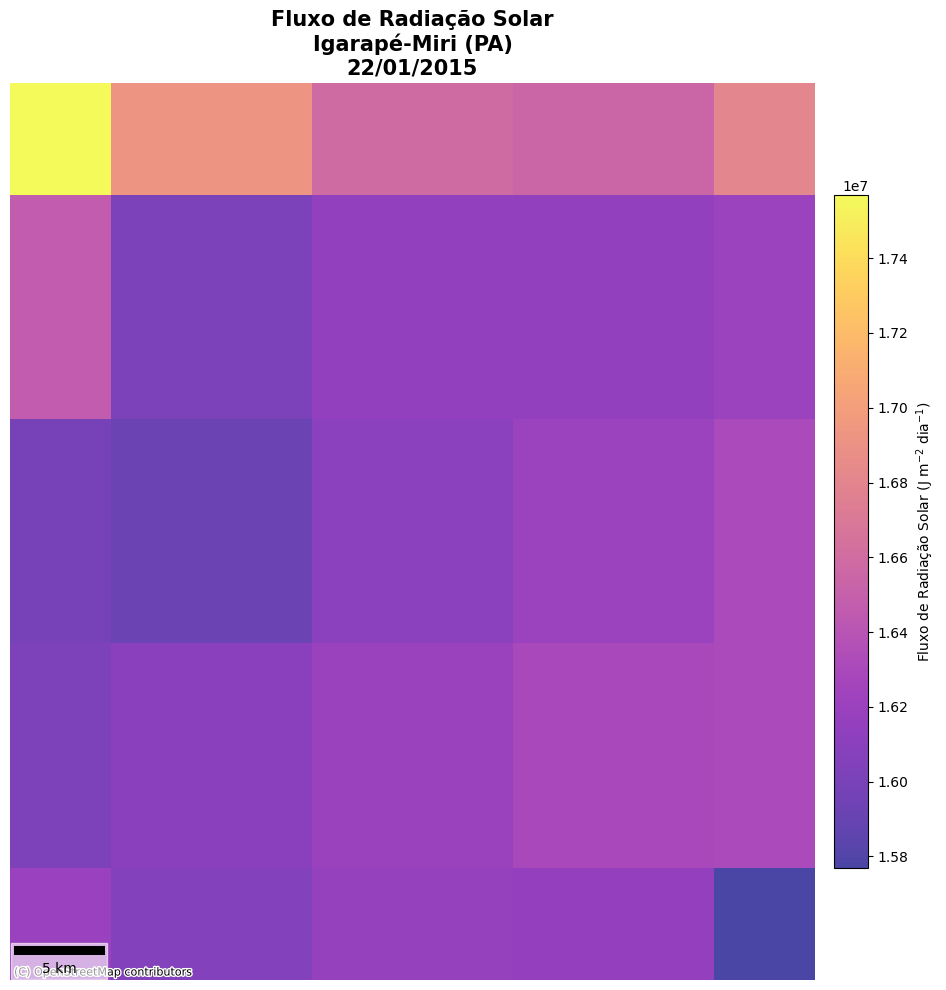

In [ ]:
# ==========================================================
# Instalar bibliotecas (caso necessário)
# ==========================================================

!pip install contextily geopandas matplotlib shapely matplotlib-scalebar rasterio

import matplotlib.pyplot as plt
import contextily as ctx
import xarray as xr
import numpy as np
from pyproj import Transformer
from matplotlib_scalebar.scalebar import ScaleBar

# ==========================================================
# ABRIR O ARQUIVO NETCDF
# ==========================================================

ds = xr.open_dataset(
    "radiacao/Solar-Radiation-Flux_C3S-glob-agric_AgERA5_20150122_final-v2.0.0.area-subset.-1.75.-48.7.-2.25.-49.2.nc"
)

# Variável
rad = ds["Solar_Radiation_Flux"].isel(time=0)

# Coordenadas
lon = ds.lon.values
lat = ds.lat.values

# ==========================================================
# CONVERTER PARA WEB MERCATOR (igual ao código do professor)
# ==========================================================

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3857",
    always_xy=True
)

lon2d, lat2d = np.meshgrid(lon, lat)

x, y = transformer.transform(lon2d, lat2d)

# ==========================================================
# MAPA
# ==========================================================

fig, ax = plt.subplots(figsize=(10,10))

# Fundo OpenStreetMap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=11
)

# Raster da radiação
pcm = ax.pcolormesh(
    x,
    y,
    rad.values,
    cmap="plasma",
    shading="nearest",
    alpha=0.75
)

# Barra de cores
cbar = plt.colorbar(
    pcm,
    ax=ax,
    shrink=0.75,
    pad=0.02
)

cbar.set_label("Fluxo de Radiação Solar (J m$^{-2}$ dia$^{-1}$)")

# Barra de escala
scalebar = ScaleBar(
    1,
    units="m",
    dimension="si-length",
    location="lower left",
    box_alpha=0.6
)

ax.add_artist(scalebar)

# Limites da área (Igarapé-Miri)

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Remove eixos
ax.set_axis_off()

plt.title(
    "Fluxo de Radiação Solar\nIgarapé-Miri (PA)\n22/01/2015",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "Fluxo_Radiacao_Igarape_Miri_OSM.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 38.6 MB/s eta 0:00:00


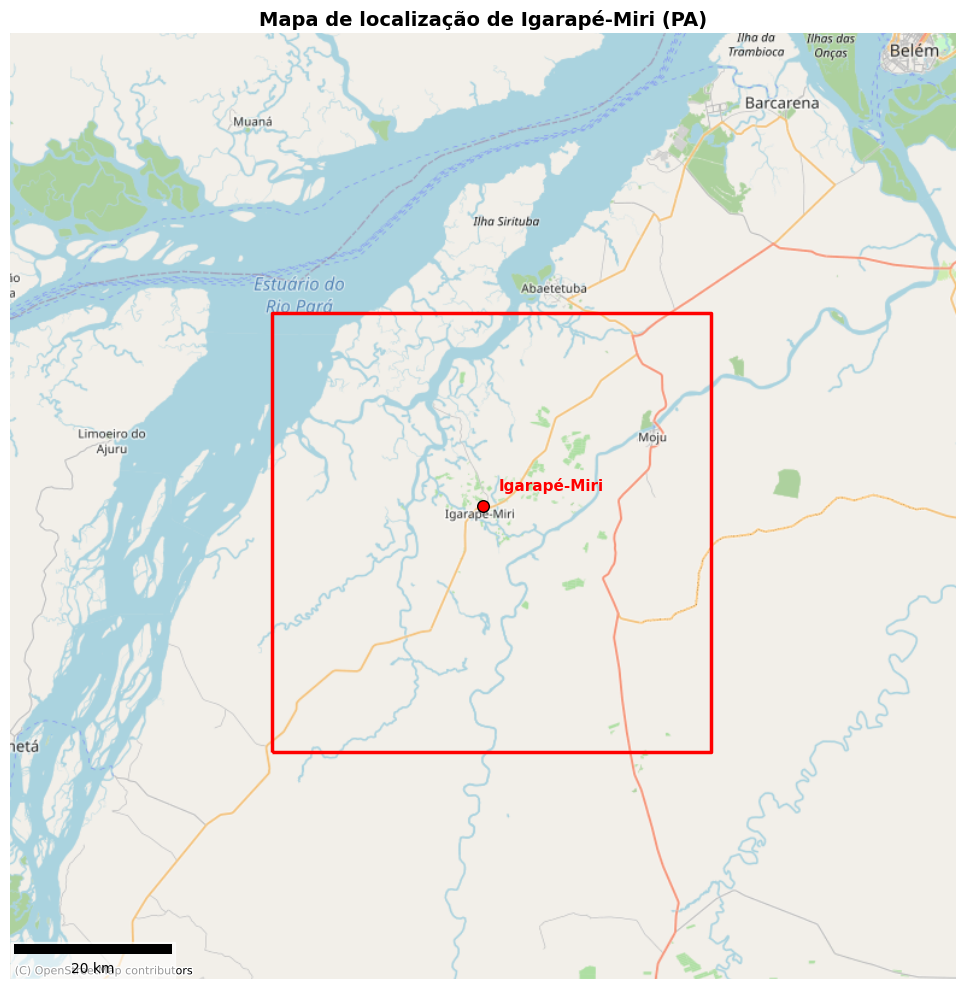

In [ ]:
# Instale as bibliotecas (caso necessário)
!pip install cartopy contextily geopandas matplotlib mercantile xyzservices matplotlib-scalebar

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# -----------------------------
# Coordenadas de Igarapé-Miri
# -----------------------------
lon = -48.96
lat = -1.97

# Cria ponto
gdf = gpd.GeoDataFrame(
    geometry=[Point(lon, lat)],
    crs="EPSG:4326"
)

# Converte para Web Mercator
gdf = gdf.to_crs(epsg=3857)

x = gdf.geometry.x.iloc[0]
y = gdf.geometry.y.iloc[0]

# -----------------------------
# QUADRADO (área do município)
# -----------------------------
lon_min = -49.20
lon_max = -48.70
lat_min = -2.25
lat_max = -1.75

quad = gpd.GeoDataFrame(
    geometry=[box(lon_min, lat_min, lon_max, lat_max)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

# -----------------------------
# MAPA
# -----------------------------
fig, ax = plt.subplots(figsize=(10,10))

# Ponto
ax.scatter(
    x, y,
    color='red',
    s=70,
    edgecolor='black',
    zorder=5
)

ax.text(
    x + 2000,
    y + 2000,
    "Igarapé-Miri",
    fontsize=11,
    color='red',
    weight='bold'
)

# Quadrado do município
quad.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2.5,
    zorder=4
)

# Extensão do mapa
dist = 60000
ax.set_xlim(x - dist, x + dist)
ax.set_ylim(y - dist, y + dist)

# Fundo OSM
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

# -----------------------------
# ESCALA DO MAPA
# -----------------------------
scalebar = ScaleBar(
    1,               # 1 pixel = 1 unidade do CRS (Web Mercator)
    units="m",
    dimension="si-length",
    location="lower left",
    box_alpha=0.6,
    color="black"
)

ax.add_artist(scalebar)

# -----------------------------
# Finalização
# -----------------------------
ax.set_axis_off()

plt.title(
    "Mapa de localização de Igarapé-Miri (PA)",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()
plt.savefig(
    "Mapa_Localizacao_Igarape_Miri_OSM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import cdsapi

dataset = "reanalysis-era5-land-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": [
        "2m_dewpoint_temperature",
        "2m_temperature",
        "skin_temperature",
        "soil_temperature_level_1",
        "soil_temperature_level_2",
        "soil_temperature_level_3",
        "soil_temperature_level_4",
        "lake_total_layer_temperature",
        "temperature_of_snow_layer",
        "skin_reservoir_content",
        "forecast_albedo",
        "surface_latent_heat_flux",
        "surface_net_solar_radiation",
        "surface_net_thermal_radiation",
        "surface_sensible_heat_flux",
        "surface_solar_radiation_downwards",
        "surface_thermal_radiation_downwards",
        "evaporation_from_bare_soil",
        "evaporation_from_open_water_surfaces_excluding_oceans",
        "evaporation_from_the_top_of_canopy",
        "evaporation_from_vegetation_transpiration",
        "potential_evaporation",
        "runoff",
        "snow_evaporation",
        "sub_surface_runoff",
        "surface_runoff",
        "total_evaporation",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "surface_pressure",
        "total_precipitation",
        "leaf_area_index_high_vegetation",
        "leaf_area_index_low_vegetation",
        "high_vegetation_cover",
        "glacier_mask",
        "lake_cover",
        "low_vegetation_cover",
        "lake_total_depth",
        "geopotential",
        "land_sea_mask",
        "soil_type",
        "type_of_high_vegetation",
        "type_of_low_vegetation"
    ],
    "year": ["2025"],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [-1.6, -49.35, -2.4, -48.55]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='6fff0335-1b30-4f92-9857-684fb8d68829', verify=False)
client.retrieve(dataset, request).download()

ModuleNotFoundError: No module named 'cdsapi'

In [ ]:
!pip install -q cdsapi

In [ ]:
import cdsapi

print(cdsapi.__version__)

AttributeError: module 'cdsapi' has no attribute '__version__'

In [ ]:
import cdsapi

dataset = "reanalysis-era5-land-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": [
        "2m_dewpoint_temperature",
        "2m_temperature",
        "skin_temperature",
        "soil_temperature_level_1",
        "soil_temperature_level_2",
        "soil_temperature_level_3",
        "soil_temperature_level_4",
        "lake_total_layer_temperature",
        "temperature_of_snow_layer",
        "skin_reservoir_content",
        "forecast_albedo",
        "surface_latent_heat_flux",
        "surface_net_solar_radiation",
        "surface_net_thermal_radiation",
        "surface_sensible_heat_flux",
        "surface_solar_radiation_downwards",
        "surface_thermal_radiation_downwards",
        "evaporation_from_bare_soil",
        "evaporation_from_open_water_surfaces_excluding_oceans",
        "evaporation_from_the_top_of_canopy",
        "evaporation_from_vegetation_transpiration",
        "potential_evaporation",
        "runoff",
        "snow_evaporation",
        "sub_surface_runoff",
        "surface_runoff",
        "total_evaporation",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "surface_pressure",
        "total_precipitation",
        "leaf_area_index_high_vegetation",
        "leaf_area_index_low_vegetation",
        "high_vegetation_cover",
        "glacier_mask",
        "lake_cover",
        "low_vegetation_cover",
        "lake_total_depth",
        "geopotential",
        "land_sea_mask",
        "soil_type",
        "type_of_high_vegetation",
        "type_of_low_vegetation"
    ],
    "year": ["2025"],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [-1.6, -49.35, -2.4, -48.55]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='6fff0335-1b30-4f92-9857-684fb8d68829', verify=False)
client.retrieve(dataset, request).download()

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-07-01 16:57:04,503 INFO Request 

d67eb8df22a3d719a11592e50836163e.zip:   0%|          | 0.00/446k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


'd67eb8df22a3d719a11592e50836163e.zip'

In [ ]:
import os
os.listdir()

['.config',
 'd67eb8df22a3d719a11592e50836163e.zip',
 'Mapa_Localizacao_Igarape_Miri_OSM.png',
 'drive',
 'sample_data']

In [ ]:
print(ds)

NameError: name 'ds' is not defined

In [ ]:
import zipfile

with zipfile.ZipFile("d67eb8df22a3d719a11592e50836163e.zip", "r") as zip_ref:
    zip_ref.extractall("era5_land")

In [ ]:
import os

os.listdir("era5_land")

['cvl.area-subset.-1.6.-48.55.-2.4.-49.35.nc',
 'lsm.area-subset.-1.6.-48.55.-2.4.-49.35.nc',
 'slt.area-subset.-1.6.-48.55.-2.4.-49.35.nc',
 'dl.area-subset.-1.6.-48.55.-2.4.-49.35.nc',
 'cvh.area-subset.-1.6.-48.55.-2.4.-49.35.nc',
 'clake.area-subset.-1.6.-48.55.-2.4.-49.35.nc',
 'cicecap.area-subset.-1.6.-48.55.-2.4.-49.35.nc',
 'data_stream-moda.nc',
 'tvh.area-subset.-1.6.-48.55.-2.4.-49.35.nc',
 'tvl.area-subset.-1.6.-48.55.-2.4.-49.35.nc',
 'geo.area-subset.-1.6.-48.55.-2.4.-49.35.nc']

In [ ]:
import xarray as xr

ds = xr.open_dataset("era5_land/data_stream-moda.nc")

print(ds)

<xarray.Dataset> Size: 101kB
Dimensions:     (valid_time: 12, latitude: 9, longitude: 8)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 96B 2025-01-01 ... 2025-12-01
  * latitude    (latitude) float64 72B -1.6 -1.7 -1.8 -1.9 ... -2.2 -2.3 -2.4
  * longitude   (longitude) float64 64B -49.3 -49.2 -49.1 ... -48.8 -48.7 -48.6
    number      int64 8B ...
    expver      (valid_time) <U4 192B ...
Data variables: (12/29)
    d2m         (valid_time, latitude, longitude) float32 3kB ...
    t2m         (valid_time, latitude, longitude) float32 3kB ...
    skt         (valid_time, latitude, longitude) float32 3kB ...
    stl1        (valid_time, latitude, longitude) float32 3kB ...
    stl2        (valid_time, latitude, longitude) float32 3kB ...
    stl3        (valid_time, latitude, longitude) float32 3kB ...
    ...          ...
    u10         (valid_time, latitude, longitude) float32 3kB ...
    v10         (valid_time, latitude, longitude) float32 3kB ...
    sp          (valid

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


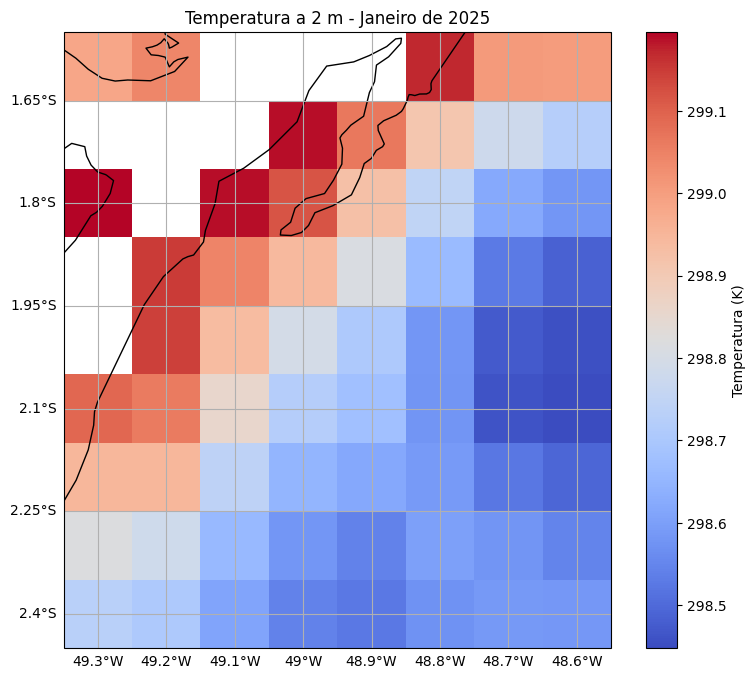

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(9,8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Janeiro = índice 0
ds["t2m"].isel(valid_time=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    cbar_kwargs={"label":"Temperatura (K)"}
)

ax.coastlines("10m")
ax.add_feature(cfeature.BORDERS)

gl = ax.gridlines(draw_labels=True)

gl.top_labels = False
gl.right_labels = False

plt.title("Temperatura a 2 m - Janeiro de 2025")

plt.show()

In [ ]:
import cdsapi

dataset = "reanalysis-era5-land-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": [
        "2m_dewpoint_temperature",
        "2m_temperature",
        "skin_temperature",
        "soil_temperature_level_1",
        "soil_temperature_level_2",
        "soil_temperature_level_3",
        "soil_temperature_level_4",
        "lake_total_layer_temperature",
        "temperature_of_snow_layer",
        "skin_reservoir_content",
        "forecast_albedo",
        "surface_latent_heat_flux",
        "surface_net_solar_radiation",
        "surface_net_thermal_radiation",
        "surface_sensible_heat_flux",
        "surface_solar_radiation_downwards",
        "surface_thermal_radiation_downwards",
        "evaporation_from_bare_soil",
        "evaporation_from_open_water_surfaces_excluding_oceans",
        "evaporation_from_the_top_of_canopy",
        "evaporation_from_vegetation_transpiration",
        "potential_evaporation",
        "runoff",
        "snow_evaporation",
        "sub_surface_runoff",
        "surface_runoff",
        "total_evaporation",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "surface_pressure",
        "total_precipitation",
        "leaf_area_index_high_vegetation",
        "leaf_area_index_low_vegetation",
        "high_vegetation_cover",
        "glacier_mask",
        "lake_cover",
        "low_vegetation_cover",
        "lake_total_depth",
        "geopotential",
        "land_sea_mask",
        "soil_type",
        "type_of_high_vegetation",
        "type_of_low_vegetation"
    ],
    "year": ["2025"],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [-0.5, -50.5, -3.5, -47.5]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='6fff0335-1b30-4f92-9857-684fb8d68829', verify=False)
client.retrieve(dataset, request).download()

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-07-01 17:17:46,353 INFO Request 

eb7631ed81dd728a43999ebf43ac0d64.zip:   0%|          | 0.00/1.11M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


'eb7631ed81dd728a43999ebf43ac0d64.zip'

In [ ]:
import os

os.listdir()

['.config',
 'era5_land',
 'd67eb8df22a3d719a11592e50836163e.zip',
 'Mapa_Localizacao_Igarape_Miri_OSM.png',
 'drive',
 'eb7631ed81dd728a43999ebf43ac0d64.zip',
 'sample_data']

In [ ]:
import zipfile

with zipfile.ZipFile("eb7631ed81dd728a43999ebf43ac0d64.zip", "r") as zip_ref:
    zip_ref.extractall("era5_land_grande")

In [ ]:
import os

os.listdir("era5_land_grande")

['slt.area-subset.-0.5.-47.5.-3.5.-50.5.nc',
 'lsm.area-subset.-0.5.-47.5.-3.5.-50.5.nc',
 'cvh.area-subset.-0.5.-47.5.-3.5.-50.5.nc',
 'tvh.area-subset.-0.5.-47.5.-3.5.-50.5.nc',
 'geo.area-subset.-0.5.-47.5.-3.5.-50.5.nc',
 'cicecap.area-subset.-0.5.-47.5.-3.5.-50.5.nc',
 'data_stream-moda.nc',
 'clake.area-subset.-0.5.-47.5.-3.5.-50.5.nc',
 'tvl.area-subset.-0.5.-47.5.-3.5.-50.5.nc',
 'dl.area-subset.-0.5.-47.5.-3.5.-50.5.nc',
 'cvl.area-subset.-0.5.-47.5.-3.5.-50.5.nc']

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


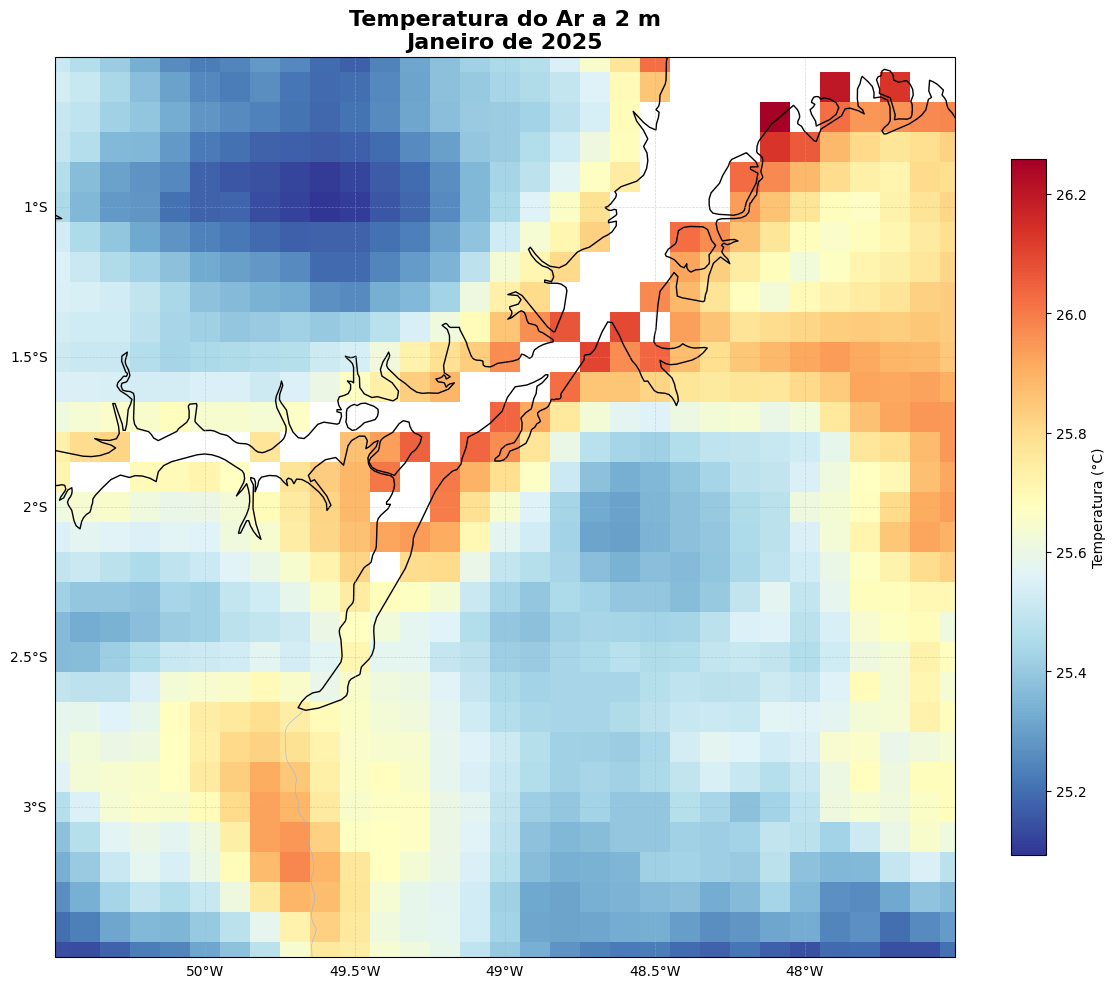

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ==========================
# Abrir o arquivo
# ==========================

ds = xr.open_dataset("era5_land_grande/data_stream-moda.nc")

# Temperatura em janeiro
temp = ds["t2m"].isel(valid_time=0) - 273.15

# ==========================
# Figura
# ==========================

fig = plt.figure(figsize=(12,10))

ax = plt.axes(projection=ccrs.PlateCarree())

# Raster
temp.plot(
    ax=ax,
    cmap="RdYlBu_r",
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        "label":"Temperatura (°C)",
        "shrink":0.75
    }
)

# Limites do mapa
ax.set_extent(
    [-50.5, -47.5, -3.5, -0.5],
    crs=ccrs.PlateCarree()
)

# Camadas
ax.coastlines("10m", linewidth=1)

ax.add_feature(cfeature.BORDERS, linewidth=0.7)

ax.add_feature(
    cfeature.LAND,
    facecolor="none"
)

ax.add_feature(
    cfeature.RIVERS,
    linewidth=0.4
)

# Grade
gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.5
)

gl.top_labels=False
gl.right_labels=False

plt.title(
    "Temperatura do Ar a 2 m\nJaneiro de 2025",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================
# Principais cidades
# ==========================

cidades = {
    "Belém": (-48.50, -1.45),
    "Barcarena": (-48.63, -1.51),
    "Abaetetuba": (-48.88, -1.72),
    "Igarapé-Miri": (-48.96, -1.97),
    "Moju": (-48.77, -1.89),
    "Cametá": (-49.50, -2.24)
}

for nome, (lon, lat) in cidades.items():
    ax.plot(
        lon,
        lat,
        marker="o",
        color="black",
        markersize=4,
        transform=ccrs.PlateCarree()
    )

    ax.text(
        lon + 0.04,
        lat + 0.04,
        nome,
        fontsize=8,
        transform=ccrs.PlateCarree()
    )

In [ ]:
cidades = {
    "Belém": (-48.50, -1.45),
    "Barcarena": (-48.63, -1.51),
    "Abaetetuba": (-48.88, -1.72),
    "Igarapé-Miri": (-48.96, -1.97),
    "Moju": (-48.77, -1.89),
    "Cametá": (-49.50, -2.24)
}

for nome, (lon, lat) in cidades.items():

    ax.scatter(
        lon,
        lat,
        s=18,
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=10
    )

    ax.text(
        lon + 0.03,
        lat + 0.03,
        nome,
        fontsize=9,
        weight="bold",
        transform=ccrs.PlateCarree(),
        zorder=10
    )

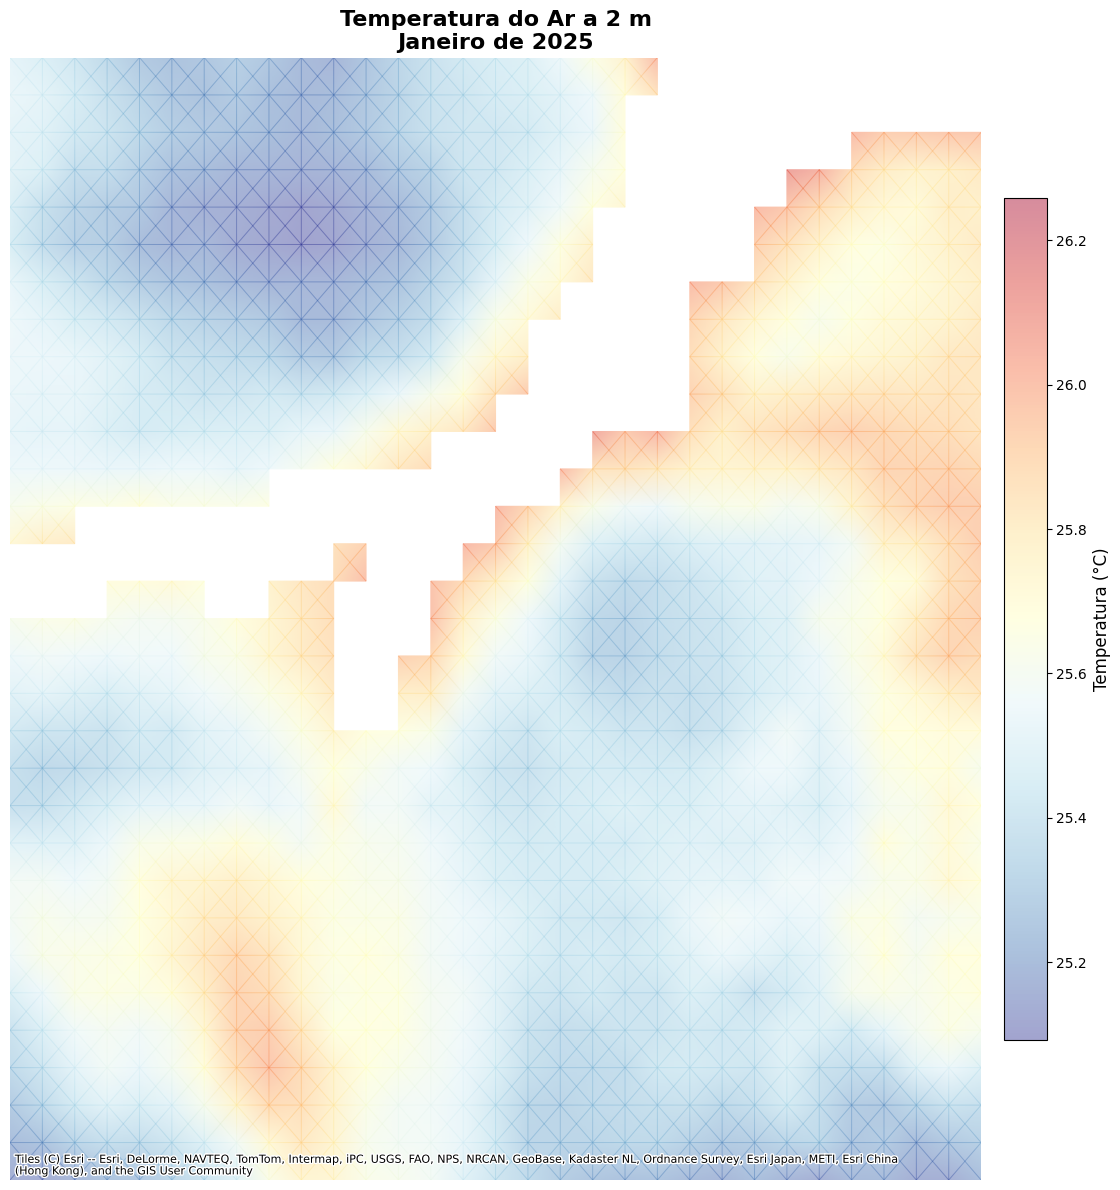

In [ ]:
# =====================================================
# Instalar bibliotecas (caso necessário)
# =====================================================

!pip install contextily geopandas rasterio pyproj

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

from pyproj import Transformer

# =====================================================
# Abrir o ERA5-Land
# =====================================================

ds = xr.open_dataset("era5_land_grande/data_stream-moda.nc")

# Janeiro de 2025
temp = ds["t2m"].isel(valid_time=0) - 273.15

# Coordenadas
lon = ds.longitude.values
lat = ds.latitude.values

lon2d, lat2d = np.meshgrid(lon, lat)

# =====================================================
# Converter para Web Mercator
# =====================================================

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3857",
    always_xy=True
)

x, y = transformer.transform(lon2d, lat2d)

# =====================================================
# Figura
# =====================================================

fig, ax = plt.subplots(figsize=(12,12))

# Fundo ESRI
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldTopoMap,
    zoom=9
)

# Temperatura
pcm = ax.pcolormesh(
    x,
    y,
    temp.values,
    cmap="RdYlBu_r",
    shading="gouraud",
    alpha=0.45
)

# Barra de cores
cbar = plt.colorbar(
    pcm,
    ax=ax,
    shrink=0.75,
    pad=0.02
)

cbar.set_label("Temperatura (°C)", fontsize=12)

# Ajustar limites
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())

# Título
plt.title(
    "Temperatura do Ar a 2 m\nJaneiro de 2025",
    fontsize=16,
    weight="bold"
)

# Remover eixos
ax.set_axis_off()

plt.tight_layout()

plt.show()